# Part 2: Evaluating One Particular Type of Alternative Data

In [1]:
!pip install kaggle

In [2]:
import json
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# Setting up kaggle credentials
api_token = {"username":"darkscientist","key":"c3986e9a57bcbaf37fe135dea39e7407"}

import json
if sys.platform.startswith("win"):
    # Windows - place in user's home .kaggle folder
    kaggle_dir = os.path.join(os.environ["USERPROFILE"], ".kaggle")
elif sys.platform == "darwin":
    # Mac OS X
    kaggle_dir = os.path.expanduser("~/.kaggle")
else:
    # Assume Linux/Unix
    kaggle_dir = os.path.expanduser("~/.kaggle")

# Create the directory if it doesn't exist
os.makedirs(kaggle_dir, exist_ok=True)

# Full path for kaggle.json
kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")

# Write the api_token to kaggle.json
with open(kaggle_json_path, "w") as file:
    json.dump(api_token, file)

# Permissions (only for Mac/Linux)
if not sys.platform.startswith("win"):
    os.chmod(kaggle_json_path, 0o600)
!chmod 600 ~/.kaggle/kaggle.json

'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# Importing libraries
import pandas as pd
import kaggle
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings', 'Employment',
           'InstallmentRate', 'PersonalStatusSex', 'Debtors', 'ResidenceSince', 'Property', 'Age',
           'OtherInstallmentPlans', 'Housing', 'ExistingCredits', 'Job', 'LiablePeople', 'Telephone',
           'ForeignWorker', 'CreditRisk']

df = pd.read_csv(url, sep=' ', header=None, names=columns)
print(df.head())

  Status  Duration CreditHistory Purpose  CreditAmount Savings Employment  \
0    A11         6           A34     A43          1169     A65        A75   
1    A12        48           A32     A43          5951     A61        A73   
2    A14        12           A34     A46          2096     A61        A74   
3    A11        42           A32     A42          7882     A61        A74   
4    A11        24           A33     A40          4870     A61        A73   

   InstallmentRate PersonalStatusSex Debtors  ...  Property Age  \
0                4               A93    A101  ...      A121  67   
1                2               A92    A101  ...      A121  22   
2                2               A93    A101  ...      A121  49   
3                2               A93    A103  ...      A122  45   
4                3               A93    A101  ...      A124  53   

   OtherInstallmentPlans Housing ExistingCredits   Job LiablePeople  \
0                   A143    A152               2  A173         

German credit dataset is used in machine learning has following attribute codes i.e. A columns

A1 Status of existing checking account
A11: ... < 0 DM
A12: 0 ≤ ... < 200 DM
A13: ≥ 200 DM / salary assignments
A14: no checking account

A3 Credit history
A30: no credits taken / all paid back duly
A31: all credits at this bank paid back duly
A32: existing credits paid back duly till now
A33: delay in paying off in the past
A34: critical account / other credits existing (not at this bank)

A4 Purpose
A40: car (new)
A41: car (used)
A42: furniture/equipment
A43: radio/television
A44: domestic appliances
A45: repairs
A46: education
A47: vacation
A48: retraining
A49: business
A410: others

A6 Savings
A61: little
A62: moderate
A63: quite rich
A64: rich
A65: unknown/ no savings account

A7 Employment
A71: unemployed
A72: < 1 year
A73: 1 ≤ ... < 4 years
A74: 4 ≤ ... < 7 years
A75: ≥ 7 years

A9 Personal status and sex
A91: male: divorced/separated
A92: female: divorced/separated/married
A93: male: single
A94: male: married/widowed
A95: female: single

A10 Other debtors/guarantors
A101: none
A102: co-applicant
A103: gurantor

A12 Property
A121: real estate
A122: building society saving
A123: car or other
A124 unknown

A14 other installment plans
A141: bank
A142: stores
A143: for free

A15 Housing
A151: rent
A152: own
A153: for free

A17 Job
A171: Unemployed
A172: Unskilled
A173: Skilled
A174: Management

Credit Risk
1: good
2: bad

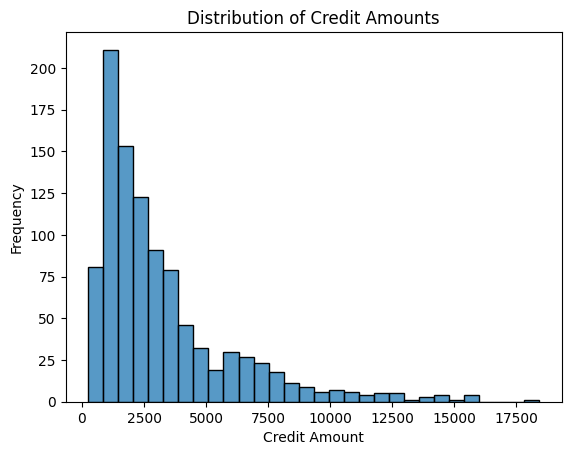

Text(0.5, 1.0, 'Age Distribution by Credit Risk')

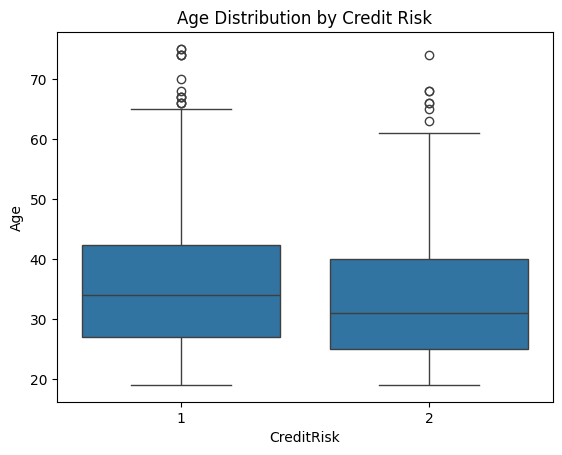

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of credit amount
sns.histplot(df['CreditAmount'], bins=30)
plt.title("Distribution of Credit Amounts")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

# Credit risk vs age
sns.boxplot(x='CreditRisk', y='Age', data=df)
plt.title("Age Distribution by Credit Risk")

The plots depict that loans are concentrated in smaller values and young people are at more risk for credit due to lower median in credit risk 2.

In [6]:
kaggle.api.dataset_download_files("darkscientist/complaints-2025-10-17-08-43-csv", path="./Datasets", unzip=True)
file_path = "./Datasets/complaints-2025-10-17_08_43.csv"

# Load a subset of columns for faster exploration
cols = [
    "Date received", "Product", "Issue", "Company",
    "State", "Submitted via", "Company response to consumer", "Timely response?"
]

complaints = pd.read_csv(file_path, usecols=cols, low_memory=False)

Dataset URL: https://www.kaggle.com/datasets/darkscientist/complaints-2025-10-17-08-43-csv


In [7]:
# View dataset info
print(complaints.info())

# Preview data
print(complaints.head())

# Check missing values
print(complaints.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592260 entries, 0 to 1592259
Data columns (total 8 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1592260 non-null  object
 1   Product                       1592260 non-null  object
 2   Issue                         1592260 non-null  object
 3   Company                       1592260 non-null  object
 4   State                         1590372 non-null  object
 5   Submitted via                 1592260 non-null  object
 6   Company response to consumer  1592260 non-null  object
 7   Timely response?              1592260 non-null  object
dtypes: object(8)
memory usage: 97.2+ MB
None
  Date received                                            Product  \
0      09/04/25  Credit reporting or other personal consumer re...   
1      10/03/25  Credit reporting or other personal consumer re...   
2      09/24/25  Credit reportin

In [8]:
# Convert date column to datetime
complaints["Date received"] = pd.to_datetime(complaints["Date received"], errors="coerce")

# Drop rows missing key fields
complaints.dropna(subset=["Product", "Company"], inplace=True)

# Normalize capitalization
complaints["Product"] = complaints["Product"].str.title()
complaints["Company response to consumer"] = complaints["Company response to consumer"].str.title()

# a. Number of complaints by product

Product
Credit Reporting Or Other Personal Consumer Reports        1449651
Debt Collection                                              74699
Credit Card                                                  23513
Checking Or Savings Account                                  17132
Money Transfer, Virtual Currency, Or Money Service            7976
Mortgage                                                      5450
Vehicle Loan Or Lease                                         4821
Student Loan                                                  3600
Payday Loan, Title Loan, Personal Loan, Or Advance Loan       3060
Prepaid Card                                                  1445
Name: count, dtype: int64


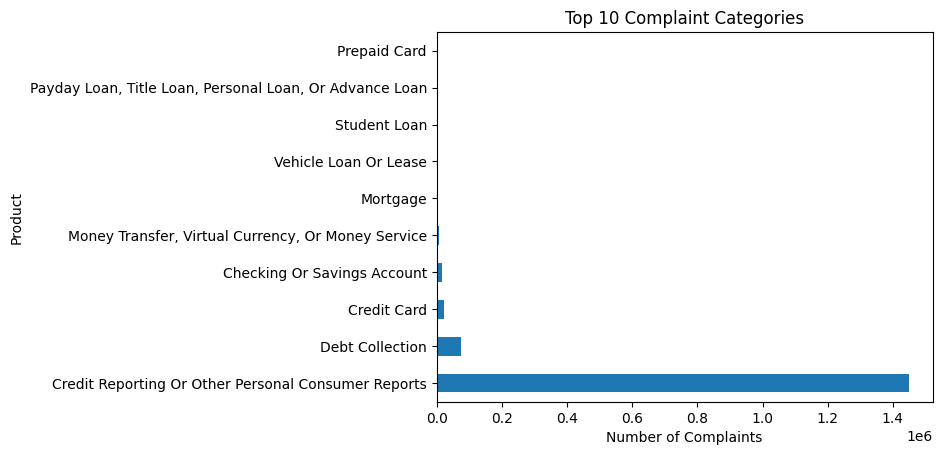

In [9]:
product_counts = complaints["Product"].value_counts().head(10)
print(product_counts)

product_counts.plot(kind="barh", title="Top 10 Complaint Categories")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()

As it can be seen that Credit Reporting is the most frequent complaint categories.

# Complaints over time

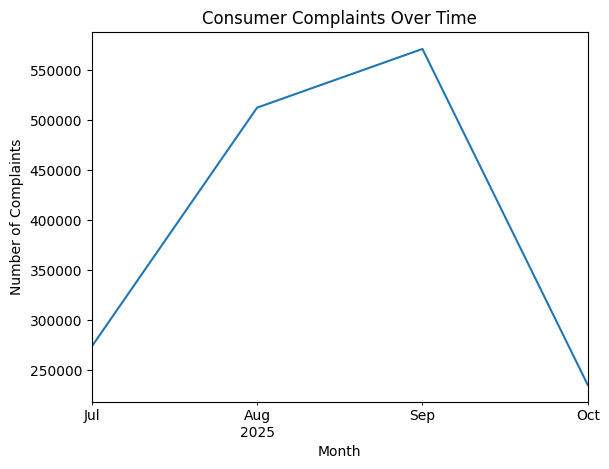

In [10]:
# Complaints per month
complaints["Month"] = complaints["Date received"].dt.to_period("M")
monthly = complaints.groupby("Month").size()

monthly.plot(title="Consumer Complaints Over Time")
plt.ylabel("Number of Complaints")
plt.show()

# Complaints by company

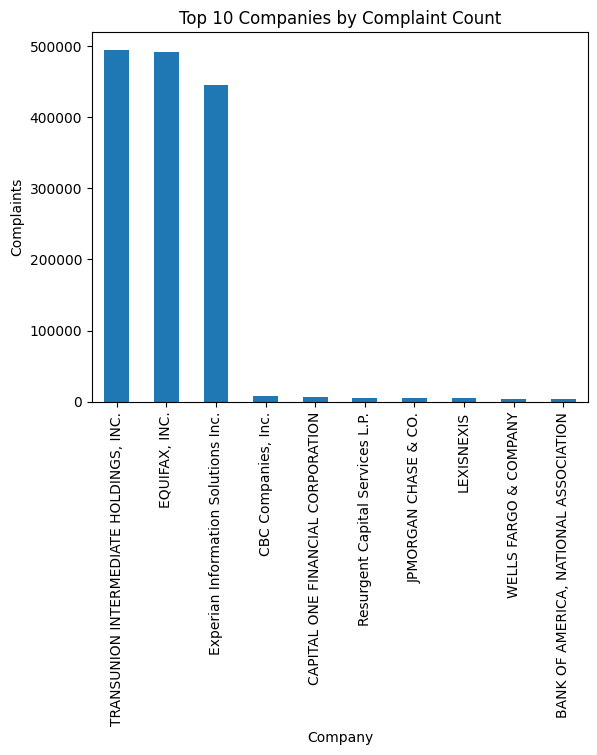

In [11]:
top_companies = complaints["Company"].value_counts().head(10)
top_companies.plot(kind="bar", title="Top 10 Companies by Complaint Count")
plt.ylabel("Complaints")
plt.show()

# Timely response rates

In [12]:
timely_rate = complaints["Timely response?"].value_counts(normalize=True) * 100
print(timely_rate)


Timely response?
Yes    99.760717
No      0.239283
Name: proportion, dtype: float64


# Credit Card Fraud Kaggle Data

In [13]:
# Load CSV
kaggle.api.dataset_download_files("darkscientist/creditcard-csv", path="./Datasets", unzip=True)
file_path = "./Datasets/creditcard.csv"
data = pd.read_csv(file_path)

# Check structure
print(data.head())
print(data.info())
print(data['Class'].value_counts())

Dataset URL: https://www.kaggle.com/datasets/darkscientist/creditcard-csv
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0

V1, V2 .. V28 are principal components (PCA transfomed features, confidential)

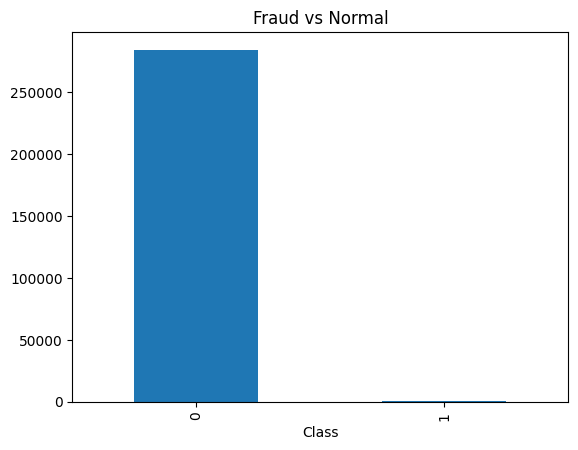

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [14]:
# Class distribution
data['Class'].value_counts().plot(kind='bar', title='Fraud vs Normal')
plt.show()

# Summary statistics
print(data.describe())